# Additional Experiment: Soft Voting Ensemble Using All 21 Features

This experiment evaluates whether combining multiple high-performing boosting models can improve fetal health classification performance.

Unlike the earlier experiments that used the 10 features selected using SelectKBest, this experiment uses all 21 original CTG input features.

Three models are trained:

- LightGBM
- XGBoost
- CatBoost

Their predicted class probabilities are then combined using a soft voting ensemble.

The ensemble is evaluated using Accuracy, Balanced Accuracy, Macro F1-score, the classification report, and the confusion matrix.

In [1]:
!pip install -q lightgbm xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [3]:
df = pd.read_csv("/content/fetal_health_cleaned.csv")

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (2113, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,...,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,...,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,...,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,...,53,170,9,0,137,136,138,11,1,1


In [4]:
X = df.drop(columns=["fetal_health"])
y = df["fetal_health"].astype(int)

print("Number of features:", X.shape[1])

print("\nClass distribution:")
print(y.value_counts().sort_index())

Number of features: 21

Class distribution:
fetal_health
1    1646
2     292
3     175
Name: count, dtype: int64


## Train-Test Split

The dataset is divided into training and testing sets using a 70:30 stratified split.

Stratification is used to preserve approximately the same class proportions in both datasets.

A fixed `random_state=42` is used for reproducibility.

Since LightGBM, XGBoost, and CatBoost are tree-based models, feature standardization is not required for this experiment.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training shape: (1479, 21)
Testing shape : (634, 21)


## LightGBM

LightGBM is a gradient boosting algorithm that constructs decision trees efficiently using a leaf-wise growth strategy.

In this experiment, LightGBM is trained using all 21 CTG features. Its predicted class probabilities are retained because they will later be used by the soft voting ensemble.

In [6]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train
)

lgbm_pred = lgbm_model.predict(X_test)

lgbm_prob = lgbm_model.predict_proba(X_test)

print(
    "LightGBM Accuracy:",
    f"{accuracy_score(y_test, lgbm_pred) * 100:.2f}%"
)

LightGBM Accuracy: 95.90%


## XGBoost

XGBoost is an optimized gradient boosting algorithm designed for efficient and regularized tree-based learning.

For multiclass classification, the target labels are temporarily converted from `1, 2, 3` to `0, 1, 2`.

The model produces probability estimates for each fetal health class, which are later combined with the other models.

In [7]:
y_train_xgb = y_train - 1

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train_xgb
)

xgb_pred_zero = xgb_model.predict(X_test)

xgb_pred = xgb_pred_zero + 1

xgb_prob = xgb_model.predict_proba(X_test)

print(
    "XGBoost Accuracy:",
    f"{accuracy_score(y_test, xgb_pred) * 100:.2f}%"
)

XGBoost Accuracy: 95.11%


## CatBoost

CatBoost is another gradient boosting algorithm that provides a robust implementation of boosted decision trees.

Although the dataset contains only numerical features, CatBoost is included because its learning procedure differs from LightGBM and XGBoost.

The model is trained on all 21 CTG features and its class probabilities are retained for ensemble prediction.

In [8]:
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=0
)

catboost_model.fit(
    X_train,
    y_train
)

catboost_pred = (
    np.asarray(
        catboost_model.predict(X_test)
    )
    .reshape(-1)
    .astype(int)
)

catboost_prob = catboost_model.predict_proba(X_test)

print(
    "CatBoost Accuracy:",
    f"{accuracy_score(y_test, catboost_pred) * 100:.2f}%"
)

CatBoost Accuracy: 94.16%


## Soft Voting Ensemble

Instead of relying on a single classifier, the predictions from LightGBM, XGBoost, and CatBoost are combined using **soft voting**.

Each model produces a probability for every fetal health class. The probabilities from the three models are averaged.

The class with the highest average probability is selected as the final prediction.

Soft voting can improve classification performance when the individual models make different errors, allowing their predictions to complement one another.

In [9]:
ensemble_prob = (
    lgbm_prob +
    xgb_prob +
    catboost_prob
) / 3

In [10]:
ensemble_pred = np.argmax(
    ensemble_prob,
    axis=1
) + 1

In [15]:
ensemble_accuracy = accuracy_score(
    y_test,
    ensemble_pred
)

ensemble_balanced_accuracy = balanced_accuracy_score(
    y_test,
    ensemble_pred
)

ensemble_macro_f1 = f1_score(
    y_test,
    ensemble_pred,
    average="macro"
)

print("-" * 60)
print("SOFT VOTING ENSEMBLE - ALL 21 FEATURES")
print("-" * 60)

print(
    f"Accuracy          : "
    f"{ensemble_accuracy * 100:.2f}%"
)

print(
    f"Balanced Accuracy : "
    f"{ensemble_balanced_accuracy * 100:.2f}%"
)

print(
    f"Macro F1          : "
    f"{ensemble_macro_f1:.4f}"
)

------------------------------------------------------------
SOFT VOTING ENSEMBLE - ALL 21 FEATURES
------------------------------------------------------------
Accuracy          : 96.06%
Balanced Accuracy : 91.82%
Macro F1          : 0.9377


In [12]:
print(
    classification_report(
        y_test,
        ensemble_pred,
        labels=[1, 2, 3],
        target_names=[
            "Normal",
            "Suspect",
            "Pathological"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9626    0.9899    0.9760       494
     Suspect     0.9200    0.7841    0.8466        88
Pathological     1.0000    0.9808    0.9903        52

    accuracy                         0.9606       634
   macro avg     0.9609    0.9182    0.9377       634
weighted avg     0.9598    0.9606    0.9593       634



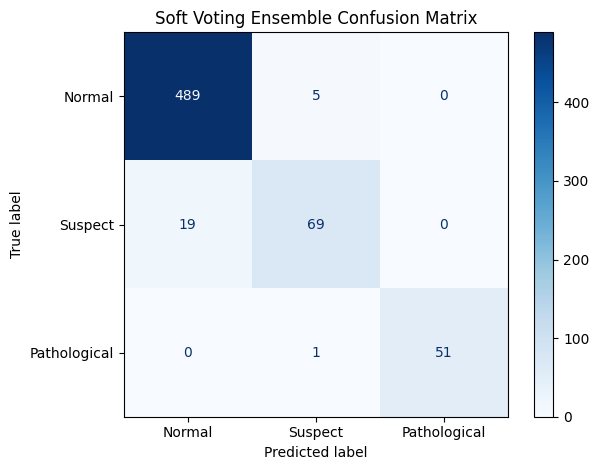

In [13]:
cm = confusion_matrix(
    y_test,
    ensemble_pred,
    labels=[1, 2, 3]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Suspect",
        "Pathological"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Soft Voting Ensemble Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [14]:
results_df = pd.DataFrame({
    "Model": [
        "LightGBM",
        "XGBoost",
        "CatBoost",
        "Soft Voting Ensemble"
    ],

    "Accuracy (%)": [
        accuracy_score(y_test, lgbm_pred) * 100,
        accuracy_score(y_test, xgb_pred) * 100,
        accuracy_score(y_test, catboost_pred) * 100,
        ensemble_accuracy * 100
    ],

    "Balanced Accuracy (%)": [
        balanced_accuracy_score(y_test, lgbm_pred) * 100,
        balanced_accuracy_score(y_test, xgb_pred) * 100,
        balanced_accuracy_score(y_test, catboost_pred) * 100,
        ensemble_balanced_accuracy * 100
    ],

    "Macro F1": [
        f1_score(y_test, lgbm_pred, average="macro"),
        f1_score(y_test, xgb_pred, average="macro"),
        f1_score(y_test, catboost_pred, average="macro"),
        ensemble_macro_f1
    ]
})

results_df[
    ["Accuracy (%)", "Balanced Accuracy (%)"]
] = results_df[
    ["Accuracy (%)", "Balanced Accuracy (%)"]
].round(2)

results_df["Macro F1"] = (
    results_df["Macro F1"]
    .round(4)
)

results_df = (
    results_df
    .sort_values(
        "Accuracy (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,Accuracy (%),Balanced Accuracy (%),Macro F1
0,Soft Voting Ensemble,96.06,91.82,0.9377
1,LightGBM,95.90,91.18,0.9257
2,XGBoost,95.11,89.34,0.9173
3,CatBoost,94.16,87.16,0.9029


In [20]:
comparison_models = pd.DataFrame({
    "Model": [
        "Soft Voting Ensemble (21 features)",
        "LightGBM",
        "XGBoost",
        "Gradient Boosting",
        "Random Forest",
        "Multi-Layer Perceptron",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Support Vector Classifier",
        "Logistic Regression",
        "Linear Support Vector"
    ],
    "Accuracy (%)": [
        96.06,
        95.90,
        95.58,
        95.58,
        95.27,
        94.95,
        93.85,
        93.22,
        91.96,
        89.59,
        89.27
    ]
})

comparison_models = comparison_models.sort_values(
    "Accuracy (%)",
    ascending=False
).reset_index(drop=True)

comparison_models

,Model,Accuracy (%)
0,Soft Voting Ensemble (21 features),96.06
1,LightGBM,95.90
2,XGBoost,95.58
3,Gradient Boosting,95.58
4,Random Forest,95.27
5,Multi-Layer Perceptron,94.95
6,K-Nearest Neighbors,93.85
7,Decision Tree,93.22
8,Support Vector Classifier,91.96
9,Logistic Regression,89.59


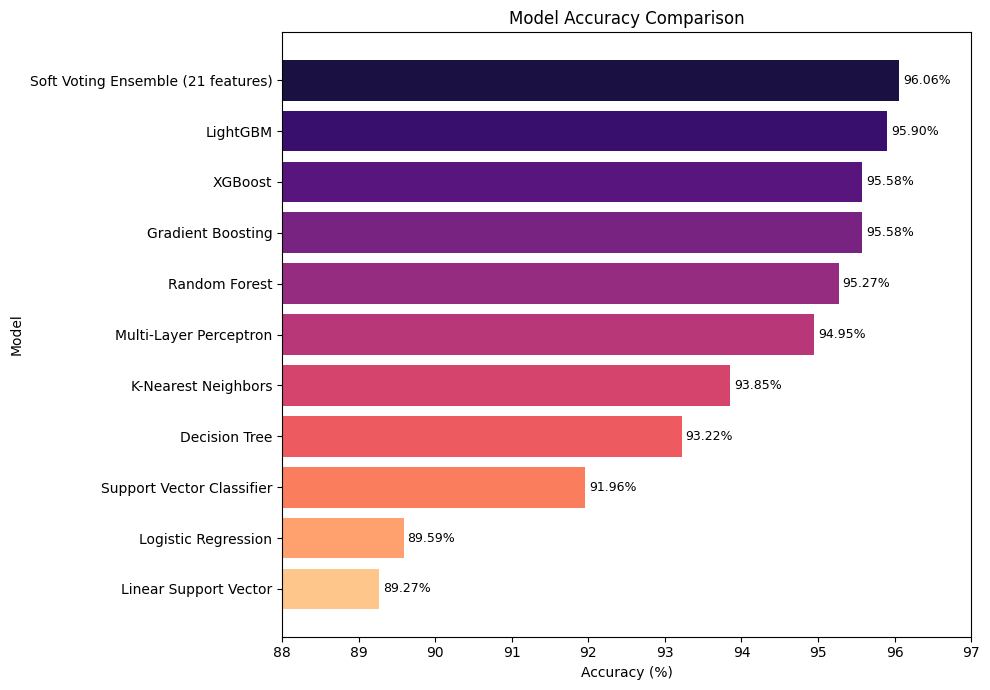

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

comparison_models = pd.DataFrame({
    "Model": [
        "Soft Voting Ensemble (21 features)",
        "LightGBM",
        "XGBoost",
        "Gradient Boosting",
        "Random Forest",
        "Multi-Layer Perceptron",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Support Vector Classifier",
        "Logistic Regression",
        "Linear Support Vector"
    ],
    "Accuracy (%)": [
        96.06,
        95.90,
        95.58,
        95.58,
        95.27,
        94.95,
        93.85,
        93.22,
        91.96,
        89.59,
        89.27
    ]
})

comparison_models = comparison_models.sort_values(
    "Accuracy (%)",
    ascending=False
).reset_index(drop=True)

# Paper-style purple → orange gradient
colors = plt.cm.magma(
    np.linspace(0.12, 0.88, len(comparison_models))
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    comparison_models["Model"],
    comparison_models["Accuracy (%)"],
    color=colors
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.title("Model Accuracy Comparison")

plt.xlim(88, 97)

# Highest-performing model at the top
plt.gca().invert_yaxis()

# Accuracy labels
for bar, value in zip(
    bars,
    comparison_models["Accuracy (%)"]
):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()